In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import string
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from wordcloud import WordCloud


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Пристрій: {DEVICE}')

MAX_VOCAB  = 15_000
MAXLEN     = 64
EMBED_DIM  = 128
HIDDEN_DIM = 128
BATCH_SIZE = 128
EPOCHS     = 15
LR         = 1e-3

Пристрій: cpu


In [5]:
train_df = pd.read_csv('nlp_train.csv', usecols=['Text', 'Emotion'])
test_df  = pd.read_csv('nlp_test.csv',  usecols=['Text', 'Emotion'])

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f"\nКласи: {sorted(train_df['Emotion'].unique())}")
train_df.head()

Train: (20387, 2)  |  Test: (1072, 2)

Класи: ['anger', 'fear', 'happy', 'love', 'sadness', 'surprise']


,Text,Emotion
0,i want them to feel eager to attend a amp m i ...,happy
1,i did feel like things were resolved a bit too...,happy
2,i said before i feel like a hypocrite advocati...,love
3,i can feel she still angry with me,anger
4,i can say that it is happening in the eastern ...,happy


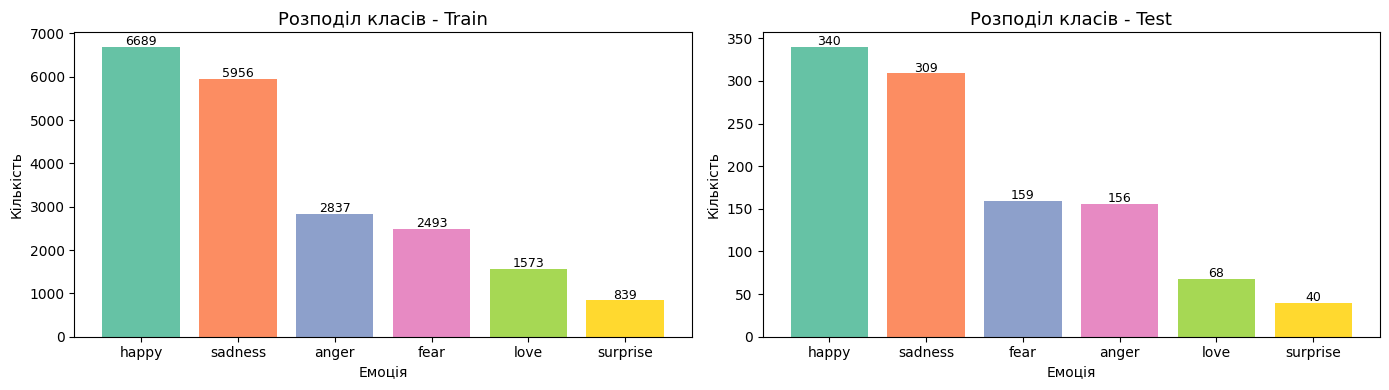


Таблиця балансу (train):
          count   pct
Emotion              
happy      6689  32.8
sadness    5956  29.2
anger      2837  13.9
fear       2493  12.2
love       1573   7.7
surprise    839   4.1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc_train = train_df['Emotion'].value_counts()
colors = sns.color_palette('Set2', len(vc_train))
axes[0].bar(vc_train.index, vc_train.values, color=colors)
axes[0].set_title('Розподіл класів - Train', fontsize=13)
axes[0].set_xlabel('Емоція'); axes[0].set_ylabel('Кількість')
for i, (label, val) in enumerate(zip(vc_train.index, vc_train.values)):
    axes[0].text(i, val + 40, str(val), ha='center', fontsize=9)

vc_test = test_df['Emotion'].value_counts()
axes[1].bar(vc_test.index, vc_test.values, color=colors)
axes[1].set_title('Розподіл класів - Test', fontsize=13)
axes[1].set_xlabel('Емоція'); axes[1].set_ylabel('Кількість')
for i, (label, val) in enumerate(zip(vc_test.index, vc_test.values)):
    axes[1].text(i, val + 2, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nТаблиця балансу (train):")
print(vc_train.to_frame().assign(pct=lambda d: (d['count']/d['count'].sum()*100).round(1)))

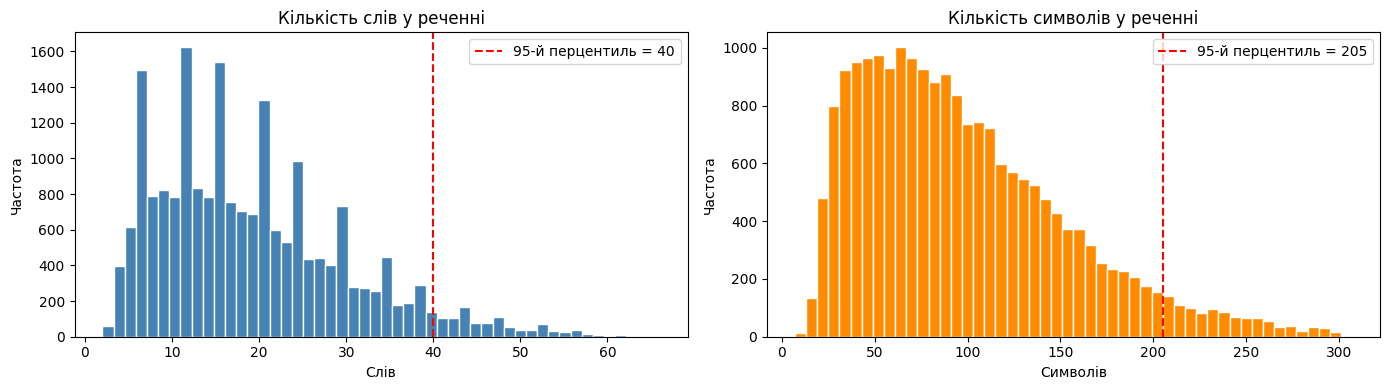

       word_count  char_count
count     20387.0     20387.0
mean         19.1        96.8
std          10.9        55.5
min           2.0         7.0
25%          11.0        54.0
50%          17.0        86.0
75%          25.0       129.0
max          66.0       307.0

Обраний MAXLEN = 64 (покриває ~95% речень)


In [7]:
train_df['word_count'] = train_df['Text'].str.split().str.len()
train_df['char_count'] = train_df['Text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['word_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['word_count'].quantile(0.95), color='red',
                linestyle='--', label=f"95-й перцентиль = {int(train_df['word_count'].quantile(0.95))}")
axes[0].set_title('Кількість слів у реченні')
axes[0].set_xlabel('Слів'); axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(train_df['char_count'], bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(train_df['char_count'].quantile(0.95), color='red',
                linestyle='--', label=f"95-й перцентиль = {int(train_df['char_count'].quantile(0.95))}")
axes[1].set_title('Кількість символів у реченні')
axes[1].set_xlabel('Символів'); axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

print(train_df[['word_count','char_count']].describe().round(1))
print(f"\nОбраний MAXLEN = {MAXLEN} (покриває ~95% речень)")

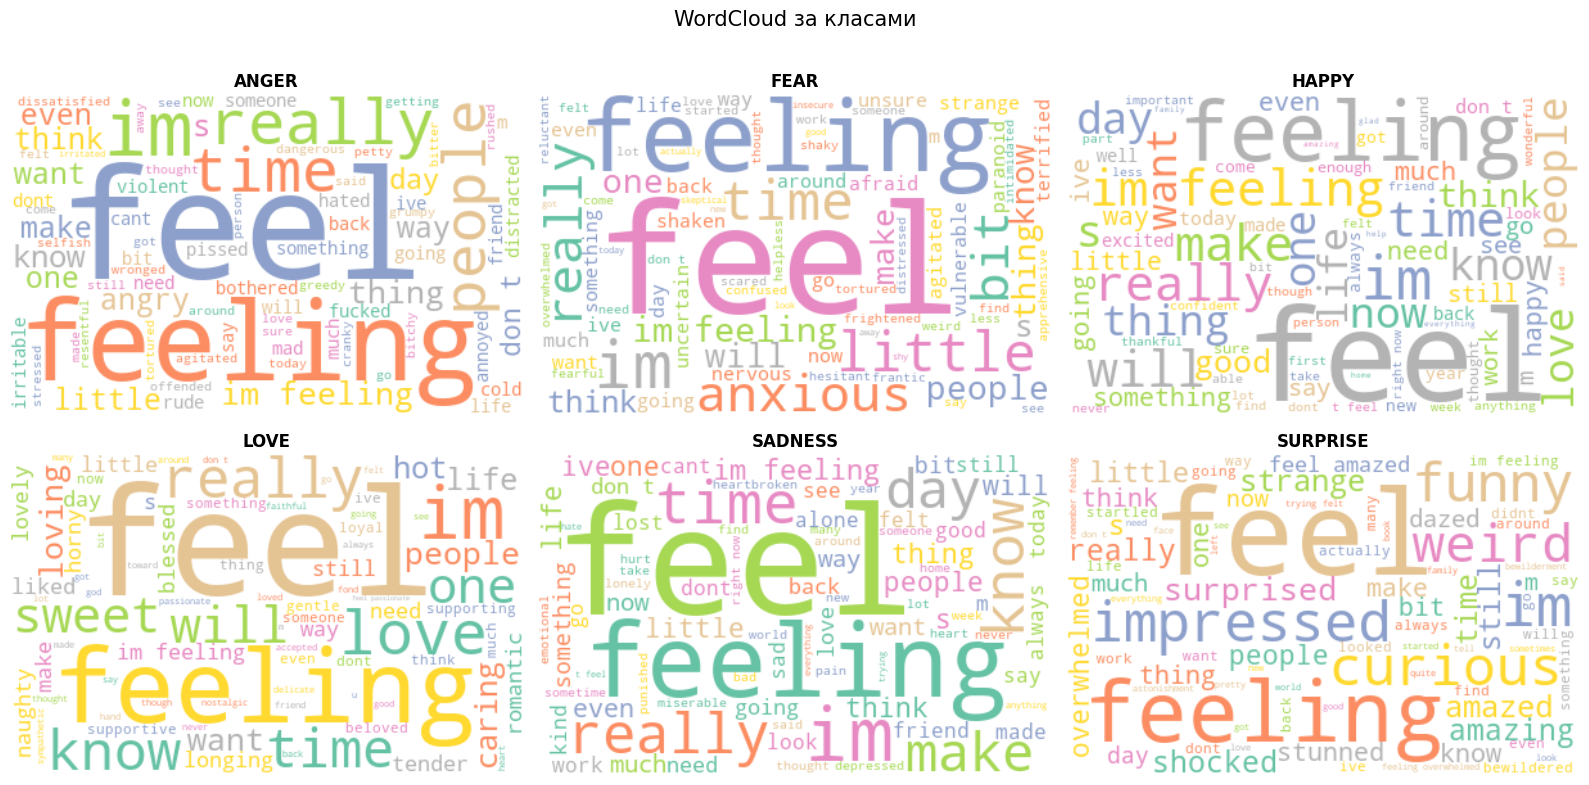

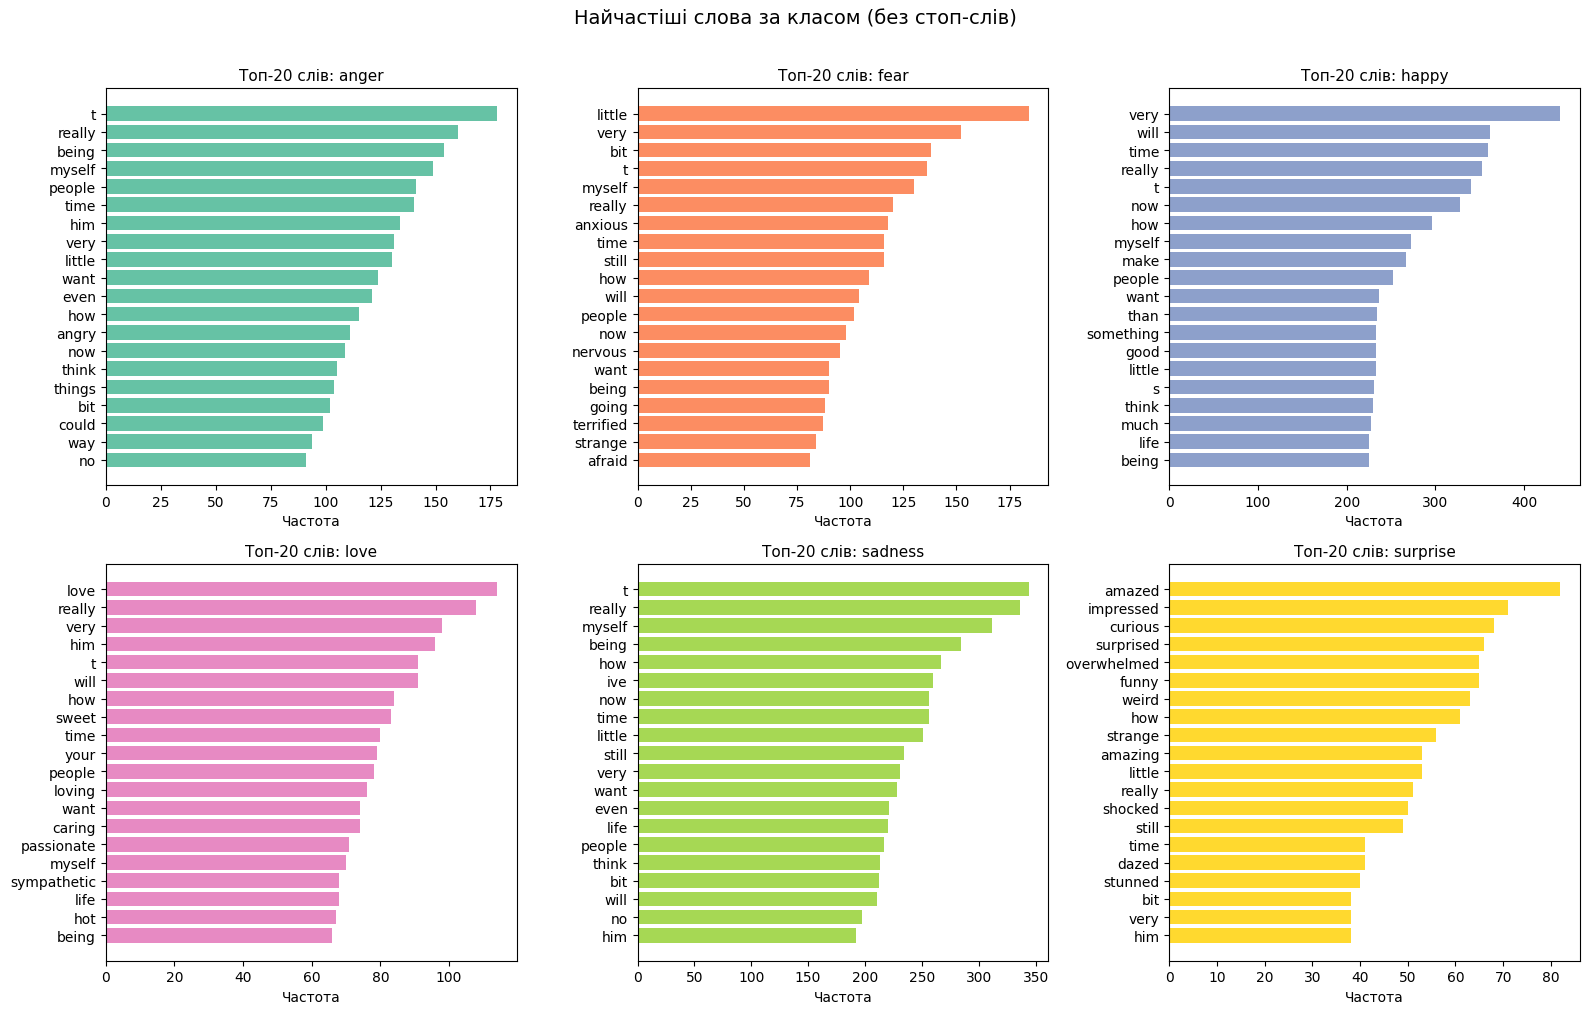

In [ ]:
emotion_classes = sorted(train_df['Emotion'].unique())
palette = sns.color_palette('Set2', len(emotion_classes))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, emotion, color in zip(axes.flat, emotion_classes, palette):
    texts = ' '.join(train_df[train_df['Emotion'] == emotion]['Text'])
    wc = WordCloud(width=400, height=250, background_color='white',
                   colormap='Set2', max_words=80).generate(texts)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(emotion.upper(), fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('WordCloud за класами', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

STOPWORDS = {'i','the','a','and','to','of','is','in','it','my','was',
             'me','that','for','on','are','with','this','he','she',
             'you','at','have','had','be','as','so','not','but','do',
             'we','his','her','an','they','from','feel','feeling','amp',
             'like','about','when','more','just','been','what','would',
             'get','got','all','im','its','if','up','out','know','one',
             'or','can','their','there','some','then','them','felt', 'am', ',', 
             'because', 'by'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, emotion, color in zip(axes.flat, emotion_classes, palette):
    words = ' '.join(train_df[train_df['Emotion'] == emotion]['Text']).split()
    freq = Counter(w.lower() for w in words if w.lower() not in STOPWORDS)
    top = pd.Series(dict(freq.most_common(20))).sort_values()
    ax.barh(top.index, top.values, color=color)
    ax.set_title(f'Топ-20 слів: {emotion}', fontsize=11)
    ax.set_xlabel('Частота')
plt.suptitle('Найчастіші слова за класом (без стоп-слів)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)     
    text = re.sub(r'[^a-z\s]', '', text)          
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean'] = train_df['Text'].apply(clean_text)
test_df ['clean'] = test_df ['Text'].apply(clean_text)

print("Приклад очищення:")
for orig, cl in zip(train_df['Text'][:3], train_df['clean'][:3]):
    print(f"  BEFORE: {orig[:80]}")
    print(f"  AFTER : {cl[:80]}\n")

Приклад очищення:
  BEFORE: i want them to feel eager to attend a amp m i want them to feel like they belong
  AFTER : i want them to feel eager to attend a amp m i want them to feel like they belong

  BEFORE: i did feel like things were resolved a bit too quickly at the end though i am in
  AFTER : i did feel like things were resolved a bit too quickly at the end though i am in

  BEFORE: i said before i feel like a hypocrite advocating for diabetes support and awaren
  AFTER : i said before i feel like a hypocrite advocating for diabetes support and awaren



In [10]:
all_words = ' '.join(train_df['clean']).split()
word_freq = Counter(all_words)

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in word_freq.most_common(MAX_VOCAB - 2):
    word2idx[word] = len(word2idx)

VOCAB_SIZE = len(word2idx)
print(f'Розмір словника: {VOCAB_SIZE}')

def tokenize(text: str, maxlen: int = MAXLEN) -> list[int]:
    tokens = [word2idx.get(w, 1) for w in text.split()]
    if len(tokens) >= maxlen:
        return tokens[:maxlen]
    return [0] * (maxlen - len(tokens)) + tokens

X_train = np.array([tokenize(t) for t in train_df['clean']], dtype=np.int64)
X_test  = np.array([tokenize(t) for t in test_df ['clean']], dtype=np.int64)

le = LabelEncoder()
y_train = le.fit_transform(train_df['Emotion'])
y_test  = le.transform(test_df ['Emotion'])
NUM_CLASSES = len(le.classes_)

print(f'Класи: {list(le.classes_)}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Розмір словника: 15000
Класи: ['anger', 'fear', 'happy', 'love', 'sadness', 'surprise']
X_train: (20387, 64)  |  X_test: (1072, 64)


In [11]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = EmotionDataset(X_train, y_train)
test_ds  = EmotionDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches train: {len(train_loader)}  |  test: {len(test_loader)}')

Batches train: 160  |  test: 9


In [12]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 rnn_type='LSTM', num_layers=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        factor = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * factor, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.rnn(emb)
        last = out[:, -1, :]                          
        return self.fc(self.dropout(last))              

sample = torch.randint(0, VOCAB_SIZE, (4, MAXLEN))
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    m = RNNClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, rnn_type)
    out = m(sample)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{rnn_type:4s}  output shape: {tuple(out.shape)}  | параметрів: {n_params:,}')

RNN   output shape: (4, 6)  | параметрів: 1,986,822
LSTM  output shape: (4, 6)  | параметрів: 2,184,966
GRU   output shape: (4, 6)  | параметрів: 2,118,918


In [13]:
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [],
                'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(correct / total)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss    += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
                val_total   += len(y_batch)

        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(val_correct / val_total)
        scheduler.step()

        if epoch % 3 == 0 or epoch == 1:
            print(f"Epoch {epoch:2d}/{epochs} | "
                  f"train loss {history['train_loss'][-1]:.4f}, acc {history['train_acc'][-1]:.4f} | "
                  f"val loss {history['val_loss'][-1]:.4f}, acc {history['val_acc'][-1]:.4f}")

    return model, history

In [14]:
models_config = {
    'Simple RNN': dict(rnn_type='RNN',  num_layers=2, bidirectional=False),
    'LSTM':       dict(rnn_type='LSTM', num_layers=2, bidirectional=False),
    'GRU':        dict(rnn_type='GRU',  num_layers=2, bidirectional=False),
}

trained_models = {}
histories      = {}

for name, cfg in models_config.items():
    print(f"Навчання: {name}")
    model = RNNClassifier(
        VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, **cfg
    )
    model, hist = train_model(model, train_loader, test_loader)
    trained_models[name] = model
    histories[name] = hist

Навчання: Simple RNN
Epoch  1/15 | train loss 1.6103, acc 0.3246 | val loss 1.5685, acc 0.3405
Epoch  3/15 | train loss 1.4868, acc 0.4121 | val loss 1.4314, acc 0.4450
Epoch  6/15 | train loss 1.0858, acc 0.6085 | val loss 0.9604, acc 0.6716
Epoch  9/15 | train loss 0.8943, acc 0.6863 | val loss 0.8002, acc 0.7323
Epoch 12/15 | train loss 0.7570, acc 0.7391 | val loss 0.6756, acc 0.7743
Epoch 15/15 | train loss 0.6880, acc 0.7651 | val loss 0.6146, acc 0.7976
Навчання: LSTM
Epoch  1/15 | train loss 1.5732, acc 0.3466 | val loss 1.4728, acc 0.3927
Epoch  3/15 | train loss 0.9120, acc 0.6788 | val loss 0.6803, acc 0.7799
Epoch  6/15 | train loss 0.3761, acc 0.8701 | val loss 0.3288, acc 0.8778
Epoch  9/15 | train loss 0.2772, acc 0.8989 | val loss 0.2842, acc 0.8853
Epoch 12/15 | train loss 0.2139, acc 0.9192 | val loss 0.2406, acc 0.9011
Epoch 15/15 | train loss 0.1855, acc 0.9292 | val loss 0.2301, acc 0.9076
Навчання: GRU
Epoch  1/15 | train loss 1.5787, acc 0.3481 | val loss 1.5233,

In [16]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)

results = {}
for name, model in trained_models.items():
    preds, labels = evaluate_model(model, test_loader)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro')
    val_loss = histories[name]['val_loss'][-1]
    results[name] = {'Accuracy': round(acc, 4), 'Val Loss': round(val_loss, 4), 'F1-macro': round(f1, 4)}

results_df = pd.DataFrame(results).T
print("\nПорівняльна таблиця результатів")
print(results_df.to_string())
results_df


Порівняльна таблиця результатів
            Accuracy  Val Loss  F1-macro
Simple RNN    0.7976    0.6146    0.6984
LSTM          0.9076    0.2301    0.8723
GRU           0.9123    0.2105    0.8711


,Accuracy,Val Loss,F1-macro
Simple RNN,0.7976,0.6146,0.6984
LSTM,0.9076,0.2301,0.8723
GRU,0.9123,0.2105,0.8711


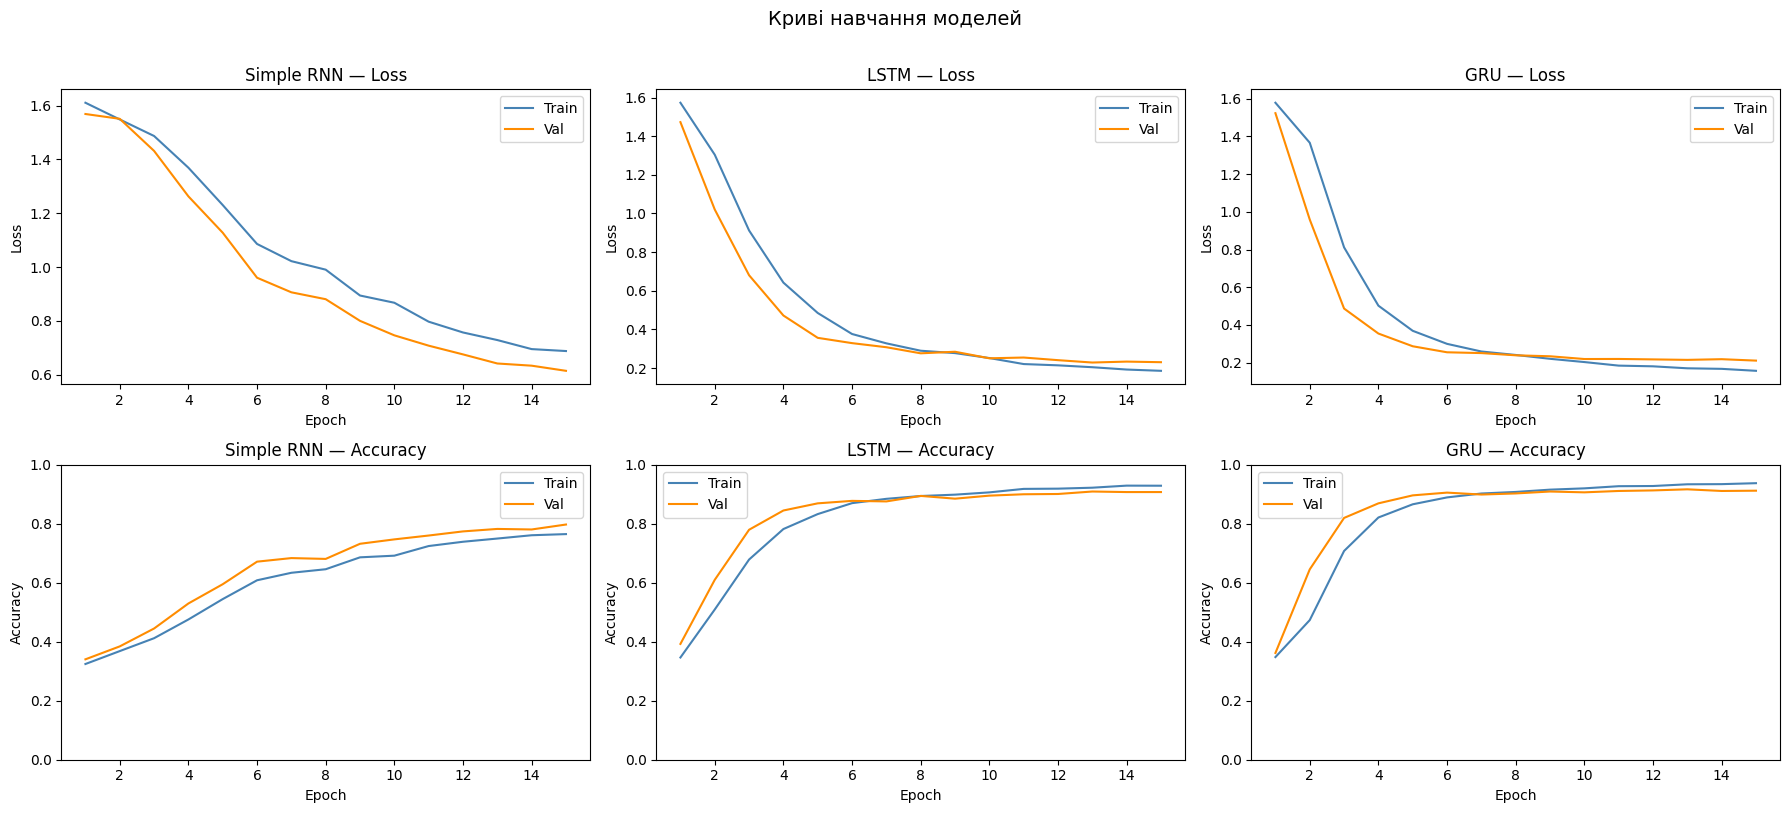

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

colors = {'train': 'steelblue', 'val': 'darkorange'}

for col, (name, hist) in enumerate(histories.items()):
    ep = range(1, len(hist['train_loss']) + 1)
    # Loss
    axes[0, col].plot(ep, hist['train_loss'], label='Train', color=colors['train'])
    axes[0, col].plot(ep, hist['val_loss'],   label='Val',   color=colors['val'])
    axes[0, col].set_title(f'{name} — Loss')
    axes[0, col].set_xlabel('Epoch'); axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    # Accuracy
    axes[1, col].plot(ep, hist['train_acc'], label='Train', color=colors['train'])
    axes[1, col].plot(ep, hist['val_acc'],   label='Val',   color=colors['val'])
    axes[1, col].set_title(f'{name} — Accuracy')
    axes[1, col].set_xlabel('Epoch'); axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_ylim([0, 1])
    axes[1, col].legend()

plt.suptitle('Криві навчання моделей', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Найкраща модель за F1-macro: LSTM


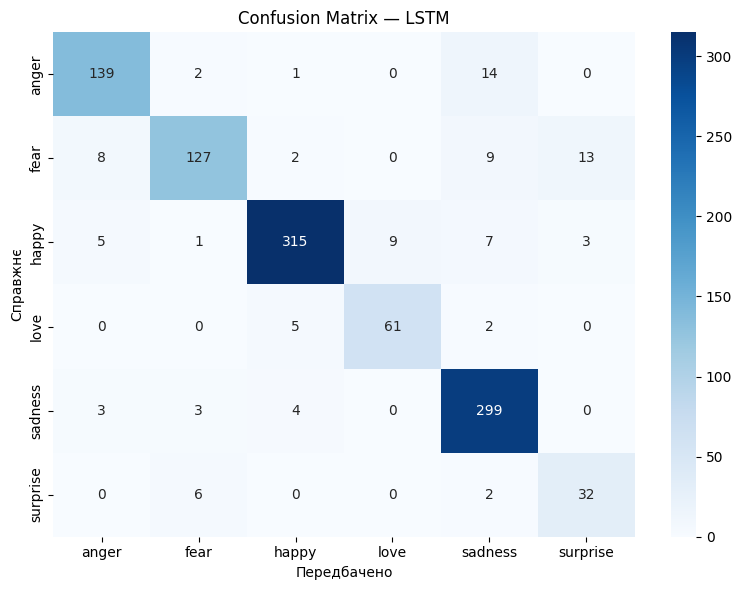


Звіт класифікації:
              precision    recall  f1-score   support

       anger       0.90      0.89      0.89       156
        fear       0.91      0.80      0.85       159
       happy       0.96      0.93      0.94       340
        love       0.87      0.90      0.88        68
     sadness       0.90      0.97      0.93       309
    surprise       0.67      0.80      0.73        40

    accuracy                           0.91      1072
   macro avg       0.87      0.88      0.87      1072
weighted avg       0.91      0.91      0.91      1072



In [18]:
best_name = results_df['F1-macro'].idxmax()
print(f'Найкраща модель за F1-macro: {best_name}')

best_model = trained_models[best_name]
preds, labels = evaluate_model(best_model, test_loader)

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_xlabel('Передбачено'); ax.set_ylabel('Справжнє')
plt.tight_layout()
plt.show()

print('\nЗвіт класифікації:')
print(classification_report(labels, preds, target_names=le.classes_))

In [19]:
best_preds, best_labels = evaluate_model(trained_models[best_name], test_loader)
test_texts = test_df['Text'].values

correct_idx = np.where(best_preds == best_labels)[0]
wrong_idx   = np.where(best_preds != best_labels)[0]

np.random.shuffle(correct_idx)
np.random.shuffle(wrong_idx)

print(f"{'5 ПРАВИЛЬНИХ ПЕРЕДБАЧЕНЬ':^70}")
for i in correct_idx[:5]:
    print(f"Текст: {test_texts[i][:90]}")
    print(f"Клас: {le.classes_[best_labels[i]]} Передбачено: {le.classes_[best_preds[i]]}")
    print()

print(f"{'5 НЕПРАВИЛЬНИ ПЕРЕДБАЧЕНЬ':^70}")
for i in wrong_idx[:5]:
    print(f"Текст: {test_texts[i][:90]}")
    print(f"Клас: {le.classes_[best_labels[i]]} Передбачено: {le.classes_[best_preds[i]]}")
    print()

                       5 ПРАВИЛЬНИХ ПЕРЕДБАЧЕНЬ                       
Текст: i feel so comfortable around him
Клас: happy Передбачено: happy

Текст: i also miss the old curious child within me i just feel that the curious child inside me i
Клас: surprise Передбачено: surprise

Текст: i am feeling completely useless lately
Клас: sadness Передбачено: sadness

Текст: i got into austin just after last night exhausted and still feeling pretty lousy from the 
Клас: sadness Передбачено: sadness

Текст: im feeling exhausted
Клас: sadness Передбачено: sadness

                      5 НЕПРАВИЛЬНИ ПЕРЕДБАЧЕНЬ                       
Текст: I 'm really frightene
Клас: fear Передбачено: anger

Текст: i enjoy reading immensely and i feel strange or off when i m in between books or just lack
Клас: surprise Передбачено: fear

Текст: when people harrass me i feel oppressed by their behavior
Клас: anger Передбачено: happy

Текст: i have just had such a crappy week that i am still feeling all agitated an


Можливі причини помилок:

1. Сарказм і іронія - модель не розуміє контексту: фраза "great, another monday" може бути гумором, а не щастям.
2. Суміш емоцій - речення може містити ознаки кількох класів одночасно (наприклад, fear + sadness).
3. Відсутність ключових слів у словнику - рідкісні або орфографічно неправильні слова отримують токен UNK, що втрачає сигнал.
4. Короткі або неповні речення - мало контексту для впевненого рішення.
5. Дисбаланс класів - класи love та surprise мають менше зразків, тому модель гірше їх розпізнає.


In [22]:
def predict_emotion(text: str, model=None, top_k: int = 3) -> None:
    if model is None:
        model = trained_models[best_name]

    model.eval()
    clean = clean_text(text)
    tokens = torch.tensor([tokenize(clean)], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        logits = model(tokens)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    top_indices = probs.argsort()[::-1][:top_k]

    print(f"\nВведений текст : {text}")
    print(f"Очищений текст : {clean}")
    print(f"\n{'Топ-' + str(top_k) + ' передбачень':}")
    for idx in top_indices:
        bar = '=' * int(probs[idx] * 30)
        print(f"  {le.classes_[idx]:10s} {bar:30s}  {probs[idx]*100:5.1f}%")
    print(f"Передбачена емоція: {le.classes_[top_indices[0]].upper()}")

test_sentences = [
    "I am so happy today, everything is going perfectly well!",
    "I feel scared and anxious about what might happen tomorrow.",
    "I can't believe how angry I am right now, this is outrageous!",
    "I feel so lonely and sad, nothing seems to matter anymore.",
    "Wow, I didn't expect that at all, what a surprise!",
    "You make me feel so loved and appreciated every single day.",
]

for sentence in test_sentences:
    predict_emotion(sentence)
    print()


Введений текст : I am so happy today, everything is going perfectly well!
Очищений текст : i am so happy today everything is going perfectly well

Топ-3 передбачень
  happy      =============================    99.7%
  anger                                        0.1%
  sadness                                      0.1%
Передбачена емоція: HAPPY


Введений текст : I feel scared and anxious about what might happen tomorrow.
Очищений текст : i feel scared and anxious about what might happen tomorrow

Топ-3 передбачень
  fear       =============================   100.0%
  surprise                                     0.0%
  anger                                        0.0%
Передбачена емоція: FEAR


Введений текст : I can't believe how angry I am right now, this is outrageous!
Очищений текст : i cant believe how angry i am right now this is outrageous

Топ-3 передбачень
  anger      ================                 56.0%
  sadness    ====                             15.2%
  fear       === 

In [23]:
MY_SENTENCE = "I feel so nervous and worried about the exam results."

predict_emotion(MY_SENTENCE)


Введений текст : I feel so nervous and worried about the exam results.
Очищений текст : i feel so nervous and worried about the exam results

Топ-3 передбачень
  fear       =============================   100.0%
  anger                                        0.0%
  surprise                                     0.0%
Передбачена емоція: FEAR
